In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  0. IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import datetime

# Paleta corporativa de cobranzas
PALETTE = {
    "rojo":     "#C0392B",
    "naranja":  "#E67E22",
    "amarillo": "#F1C40F",
    "verde":    "#27AE60",
    "azul":     "#2980B9",
    "morado":   "#8E44AD",
    "gris":     "#7F8C8D",
    "dark":     "#2C3E50",
    "light":    "#ECF0F1",
}

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
})

np.random.seed(42)

print("=" * 70)
print("  RECUPERACIÓN DE COBRANZAS — ANÁLISIS PISE 9 DÍAS")
print("=" * 70)

  RECUPERACIÓN DE COBRANZAS — ANÁLISIS PISE 9 DÍAS


##### 1. GENERACION DE DATOS AUXILIARES PARA EJECUCION DE SCRIPT FINAL

In [7]:
N = 15_000  # clientes en cartera con 9 días de atraso

# — Datos demográficos
edades    = np.clip(np.random.normal(38, 11, N).astype(int), 18, 75)
generos   = np.random.choice(["M", "F", "No especificado"], N, p=[0.52, 0.45, 0.03])
regiones  = np.random.choice(
    ["Lima", "Arequipa", "Trujillo", "Cusco", "Piura", "Otros"],
    N, p=[0.42, 0.12, 0.11, 0.09, 0.08, 0.18]
)
segmentos = np.random.choice(
    ["Masivo", "Pyme", "Consumo", "Hipotecario"],
    N, p=[0.45, 0.25, 0.20, 0.10]
)

# — Características del crédito
monto_deuda = np.where(
    segmentos == "Hipotecario",
    np.random.lognormal(11.2, 0.6, N),
    np.where(
        segmentos == "Pyme",
        np.random.lognormal(10.0, 0.8, N),
        np.where(
            segmentos == "Consumo",
            np.random.lognormal(8.8, 0.7, N),
            np.random.lognormal(8.0, 0.9, N)
        )
    )
)

antiguedad_credito = np.clip(np.random.exponential(18, N).astype(int), 1, 120)  # meses
num_cuotas_pend    = np.random.randint(1, 36, N)
tasa_interes       = np.random.choice([0.12, 0.15, 0.18, 0.24, 0.30, 0.36], N,
                                       p=[0.05, 0.15, 0.25, 0.30, 0.15, 0.10])

# — Historial de pagos
veces_en_mora_12m = np.random.poisson(1.2, N)
dias_atraso_ant   = np.clip(np.random.exponential(15, N).astype(int), 0, 180)
pagos_al_dia_12m  = np.clip(12 - veces_en_mora_12m - np.random.randint(0, 3, N), 0, 12)

# — Score interno (0–1000)
score_base = (
    500
    - veces_en_mora_12m * 30
    - (dias_atraso_ant / 180) * 100
    + pagos_al_dia_12m * 15
    - (monto_deuda / monto_deuda.max()) * 50
    + (antiguedad_credito / 120) * 80
    + np.random.normal(0, 40, N)
)
score_interno = np.clip(score_base, 200, 950).astype(int)

# — Clasificación de riesgo por score
def clasificar_riesgo(score):
    if score >= 700:   return "Bajo"
    elif score >= 550: return "Medio"
    elif score >= 400: return "Alto"
    else:              return "Muy alto"

riesgo = np.array([clasificar_riesgo(s) for s in score_interno])

# — Canal de primer contacto
canales = np.random.choice(
    ["SMS", "Llamada", "WhatsApp", "Email", "App móvil", "Sin contacto"],
    N, p=[0.28, 0.22, 0.20, 0.12, 0.08, 0.10]
)

# — Intentos de contacto realizados
intentos_contacto = np.random.randint(0, 8, N)

# — ¿Prometió pagar? (promise to pay)
prob_ptp = np.where(
    canales == "Sin contacto", 0.0,
    np.where(
        canales == "Llamada", 0.45,
        np.where(
            canales == "WhatsApp", 0.38,
            np.where(
                canales == "SMS", 0.20,
                np.where(canales == "App móvil", 0.55, 0.25)
            )
        )
    )
)
prob_ptp = np.clip(prob_ptp + (score_interno - 550) / 2000, 0.0, 0.9)
ptp_flag = np.random.binomial(1, prob_ptp, N).astype(bool)

# — Variable objetivo: PAGO EFECTIVO (recuperación real)
prob_pago = (
    (score_interno / 950) * 0.35
    + ptp_flag.astype(float) * 0.25
    + (pagos_al_dia_12m / 12) * 0.15
    + (1 - veces_en_mora_12m / 12) * 0.10
    + (antiguedad_credito / 120) * 0.05
    + np.random.normal(0, 0.05, N)
)
# penalización por monto alto y atraso previo
prob_pago -= (monto_deuda / monto_deuda.max()) * 0.10
prob_pago -= (dias_atraso_ant / 180) * 0.05
prob_pago = np.clip(prob_pago, 0.02, 0.92)
pagado = np.random.binomial(1, prob_pago, N).astype(bool)

# — Monto recuperado (si pagó)
monto_recuperado = np.where(
    pagado,
    monto_deuda * np.random.uniform(0.85, 1.05, N),  # puede pagar con recargos
    0.0
)

# — Fecha de gestión (últimos 6 meses)
fecha_base = datetime.date(2024, 7, 1)
fechas     = [fecha_base + datetime.timedelta(days=int(d)) for d in np.random.randint(0, 180, N)]
mes_gestion = [f.month for f in fechas]

# ─ Construir DataFrame
df = pd.DataFrame({
    "id_cliente":          range(1, N + 1),
    "edad":                edades,
    "genero":              generos,
    "region":              regiones,
    "segmento":            segmentos,
    "monto_deuda":         monto_deuda.round(2),
    "antiguedad_credito":  antiguedad_credito,
    "num_cuotas_pend":     num_cuotas_pend,
    "tasa_interes":        tasa_interes,
    "veces_en_mora_12m":   veces_en_mora_12m,
    "dias_atraso_ant":     dias_atraso_ant,
    "pagos_al_dia_12m":    pagos_al_dia_12m,
    "score_interno":       score_interno,
    "riesgo":              riesgo,
    "canal_contacto":      canales,
    "intentos_contacto":   intentos_contacto,
    "ptp_flag":            ptp_flag.astype(int),
    "pagado":              pagado.astype(int),
    "monto_recuperado":    monto_recuperado.round(2),
    "mes_gestion":         mes_gestion,
})

tasa_recuperacion_global = df["pagado"].mean()
monto_total_cartera      = df["monto_deuda"].sum()
monto_total_recuperado   = df["monto_recuperado"].sum()

print(f"  → Dataset generado: {N:,} clientes | {df.columns.size} variables")
print(f"  → Tasa de recuperación global: {tasa_recuperacion_global:.1%}")
print(f"  → Cartera total:     S/ {monto_total_cartera:>14,.0f}")
print(f"  → Monto recuperado:  S/ {monto_total_recuperado:>14,.0f}")
print(f"  → Ratio recuperación: {monto_total_recuperado/monto_total_cartera:.1%}")

  → Dataset generado: 15,000 clientes | 20 variables
  → Tasa de recuperación global: 52.1%
  → Cartera total:     S/    307,532,148
  → Monto recuperado:  S/    149,167,598
  → Ratio recuperación: 48.5%


#### 2. ANALISIS DE KPIS DE PROMESAS DE PAGO

In [8]:
kpis = {
    "Total clientes en gestión":       N,
    "Clientes contactados":            (df["intentos_contacto"] > 0).sum(),
    "Tasa de contacto (%)":            f"{(df['canal_contacto'] != 'Sin contacto').mean():.1%}",
    "Promise to Pay (PTP)":            df["ptp_flag"].sum(),
    "Tasa PTP sobre contactados (%)":  f"{df[df['canal_contacto'] != 'Sin contacto']['ptp_flag'].mean():.1%}",
    "Cumplimiento PTP (%)":            f"{df[df['ptp_flag']==1]['pagado'].mean():.1%}",
    "Tasa recuperación total (%)":     f"{tasa_recuperacion_global:.1%}",
    "Cartera total (S/)":              f"{monto_total_cartera:,.0f}",
    "Monto recuperado (S/)":           f"{monto_total_recuperado:,.0f}",
    "Ticket promedio recuperado (S/)": f"{df[df['pagado']==1]['monto_recuperado'].mean():,.0f}",
}

print("\n  ┌─────────────────────────────────────────────────────────┐")
print("  │                  KPIs CLAVE DE COBRANZA                │")
print("  ├─────────────────────────────────────────────────────────┤")
for k, v in kpis.items():
    print(f"  │  {k:<40} {str(v):>14}  │")
print("  └─────────────────────────────────────────────────────────┘")


  ┌─────────────────────────────────────────────────────────┐
  │                  KPIs CLAVE DE COBRANZA                │
  ├─────────────────────────────────────────────────────────┤
  │  Total clientes en gestión                         15000  │
  │  Clientes contactados                              13103  │
  │  Tasa de contacto (%)                              89.9%  │
  │  Promise to Pay (PTP)                               5009  │
  │  Tasa PTP sobre contactados (%)                    36.7%  │
  │  Cumplimiento PTP (%)                              69.3%  │
  │  Tasa recuperación total (%)                       52.1%  │
  │  Cartera total (S/)                          307,532,148  │
  │  Monto recuperado (S/)                       149,167,598  │
  │  Ticket promedio recuperado (S/)                  19,073  │
  └─────────────────────────────────────────────────────────┘


#### 3. Analisis de Indicadores de Gestion de Cobranzas


[PASO 3] Generando Figura 1 — Dashboard Ejecutivo KPIs...


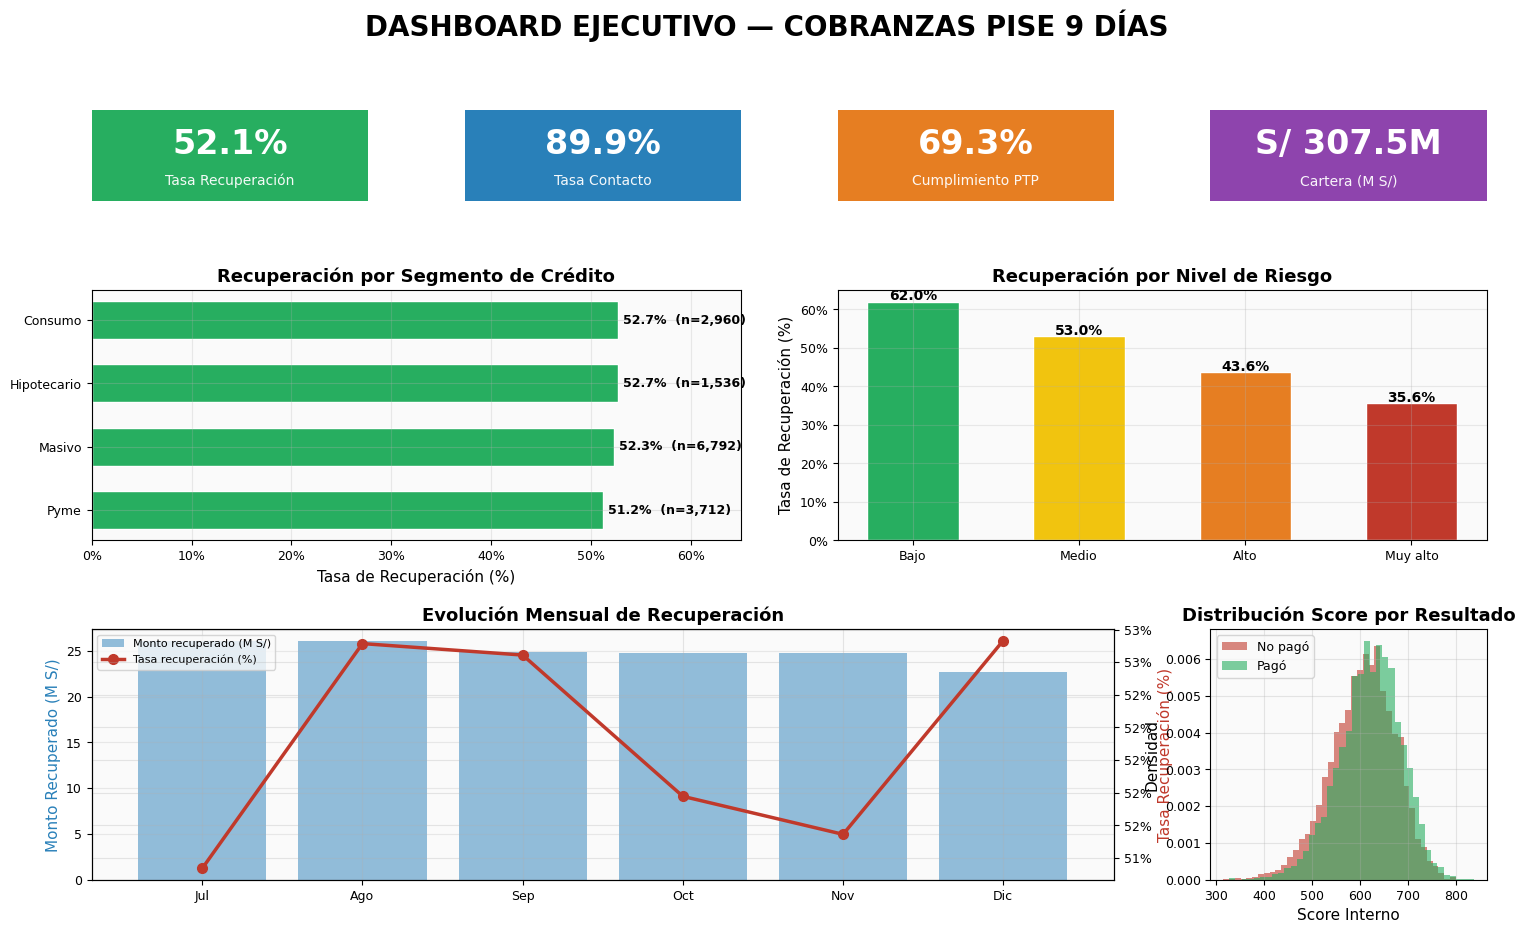

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

fig = plt.figure(figsize=(18, 10), facecolor="white")
gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    height_ratios=[0.8, 2.2, 2.2],   # <- clave
    hspace=0.45,
    wspace=0.35
)

fig.suptitle(
    "DASHBOARD EJECUTIVO — COBRANZAS PISE 9 DÍAS",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# =========================
# KPI CARDS
# =========================
kpi_cards = [
    ("Tasa Recuperación",  f"{tasa_recuperacion_global:.1%}", PALETTE["verde"]),
    ("Tasa Contacto",      f"{(df['canal_contacto'] != 'Sin contacto').mean():.1%}", PALETTE["azul"]),
    ("Cumplimiento PTP",   f"{df[df['ptp_flag']==1]['pagado'].mean():.1%}", PALETTE["naranja"]),
    ("Cartera (M S/)",     f"S/ {monto_total_cartera/1e6:.1f}M", PALETTE["morado"]),
]

for i, (titulo, valor, color) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.5, 0.62, valor,
        ha="center", va="center",
        fontsize=24, fontweight="bold", color="white",
        transform=ax.transAxes
    )
    ax.text(
        0.5, 0.22, titulo,
        ha="center", va="center",
        fontsize=10, color="white", alpha=0.95,
        transform=ax.transAxes
    )

# =========================
# RECUPERACIÓN POR SEGMENTO
# =========================
ax1 = fig.add_subplot(gs[1, :2])
seg_rec = df.groupby("segmento")["pagado"].agg(["mean", "count"]).reset_index()
seg_rec.columns = ["segmento", "tasa", "n"]
seg_rec = seg_rec.sort_values("tasa", ascending=True)

colors_seg = [
    PALETTE["rojo"] if t < 0.30 else PALETTE["naranja"] if t < 0.45 else PALETTE["verde"]
    for t in seg_rec["tasa"]
]

bars = ax1.barh(
    seg_rec["segmento"],
    seg_rec["tasa"] * 100,
    color=colors_seg,
    edgecolor="white",
    height=0.6
)

for bar, n, t in zip(bars, seg_rec["n"], seg_rec["tasa"]):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{t:.1%}  (n={n:,})",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax1.set_xlabel("Tasa de Recuperación (%)")
ax1.set_title("Recuperación por Segmento de Crédito", fontweight="bold")
ax1.set_xlim(0, 65)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax1.grid(axis="x", alpha=0.25)

# =========================
# RECUPERACIÓN POR RIESGO
# =========================
ax2 = fig.add_subplot(gs[1, 2:])
risk_order = ["Bajo", "Medio", "Alto", "Muy alto"]
risk_cols = [PALETTE["verde"], PALETTE["amarillo"], PALETTE["naranja"], PALETTE["rojo"]]

risk_data = df.groupby("riesgo")["pagado"].mean().reindex(risk_order)

ax2.bar(
    risk_data.index,
    risk_data.values * 100,
    color=risk_cols,
    edgecolor="white",
    width=0.55
)

for i, (seg, val) in enumerate(risk_data.items()):
    ax2.text(i, val * 100 + 0.5, f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")

ax2.set_ylabel("Tasa de Recuperación (%)")
ax2.set_title("Recuperación por Nivel de Riesgo", fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.grid(axis="y", alpha=0.25)

# =========================
# EVOLUCIÓN MENSUAL
# =========================
ax3 = fig.add_subplot(gs[2, :3])
mes_map = {7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

mes_df = df.groupby("mes_gestion").agg(
    tasa_rec=("pagado", "mean"),
    monto_rec=("monto_recuperado", "sum"),
    n=("pagado", "count")
).reset_index()

mes_df["mes_label"] = mes_df["mes_gestion"].map(mes_map)

ax3b = ax3.twinx()

ax3.bar(
    mes_df["mes_label"],
    mes_df["monto_rec"] / 1e6,
    color=PALETTE["azul"],
    alpha=0.5,
    label="Monto recuperado (M S/)"
)

ax3b.plot(
    mes_df["mes_label"],
    mes_df["tasa_rec"] * 100,
    color=PALETTE["rojo"],
    marker="o",
    lw=2.5,
    ms=7,
    label="Tasa recuperación (%)"
)

ax3b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax3.set_ylabel("Monto Recuperado (M S/)", color=PALETTE["azul"])
ax3b.set_ylabel("Tasa Recuperación (%)", color=PALETTE["rojo"])
ax3.set_title("Evolución Mensual de Recuperación", fontweight="bold")
ax3.grid(axis="y", alpha=0.25)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# =========================
# DISTRIBUCIÓN SCORE
# =========================
ax4 = fig.add_subplot(gs[2, 3])

ax4.hist(
    df[df["pagado"] == 0]["score_interno"],
    bins=40,
    alpha=0.6,
    color=PALETTE["rojo"],
    label="No pagó",
    density=True
)

ax4.hist(
    df[df["pagado"] == 1]["score_interno"],
    bins=40,
    alpha=0.6,
    color=PALETTE["verde"],
    label="Pagó",
    density=True
)

ax4.set_xlabel("Score Interno")
ax4.set_ylabel("Densidad")
ax4.set_title("Distribución Score por Resultado", fontweight="bold")
ax4.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### 4. Analisis de Canales de contacto para PDP

In [11]:
print("\n[PASO 4] Analizando efectividad de canales de contacto...")

canal_stats = df.groupby("canal_contacto").agg(
    n_clientes    = ("pagado", "count"),
    tasa_pago     = ("pagado", "mean"),
    tasa_ptp      = ("ptp_flag", "mean"),
    monto_rec_avg = ("monto_recuperado", "mean"),
    monto_rec_sum = ("monto_recuperado", "sum"),
).reset_index().sort_values("tasa_pago", ascending=False)

print("\n  Canal de Contacto | Clientes | Tasa Pago | Tasa PTP | Monto Rec. Prom.")
print("  " + "─" * 72)
for _, r in canal_stats.iterrows():
    print(f"  {r['canal_contacto']:<20} | {r['n_clientes']:>8,} | {r['tasa_pago']:>9.1%} | "
          f"{r['tasa_ptp']:>8.1%} | S/ {r['monto_rec_avg']:>12,.0f}")


[PASO 4] Analizando efectividad de canales de contacto...

  Canal de Contacto | Clientes | Tasa Pago | Tasa PTP | Monto Rec. Prom.
  ────────────────────────────────────────────────────────────────────────
  App móvil            |    1,182 |     59.8% |    60.0% | S/       12,233
  Llamada              |    3,348 |     56.4% |    47.1% | S/       10,564
  WhatsApp             |    3,039 |     54.1% |    41.2% | S/       10,520
  SMS                  |    4,169 |     48.9% |    22.1% | S/        9,502
  Email                |    1,753 |     48.1% |    27.8% | S/        8,977
  Sin contacto         |    1,509 |     46.4% |     4.0% | S/        7,965


#### 5. Analisis de Canales y Contactabilidad

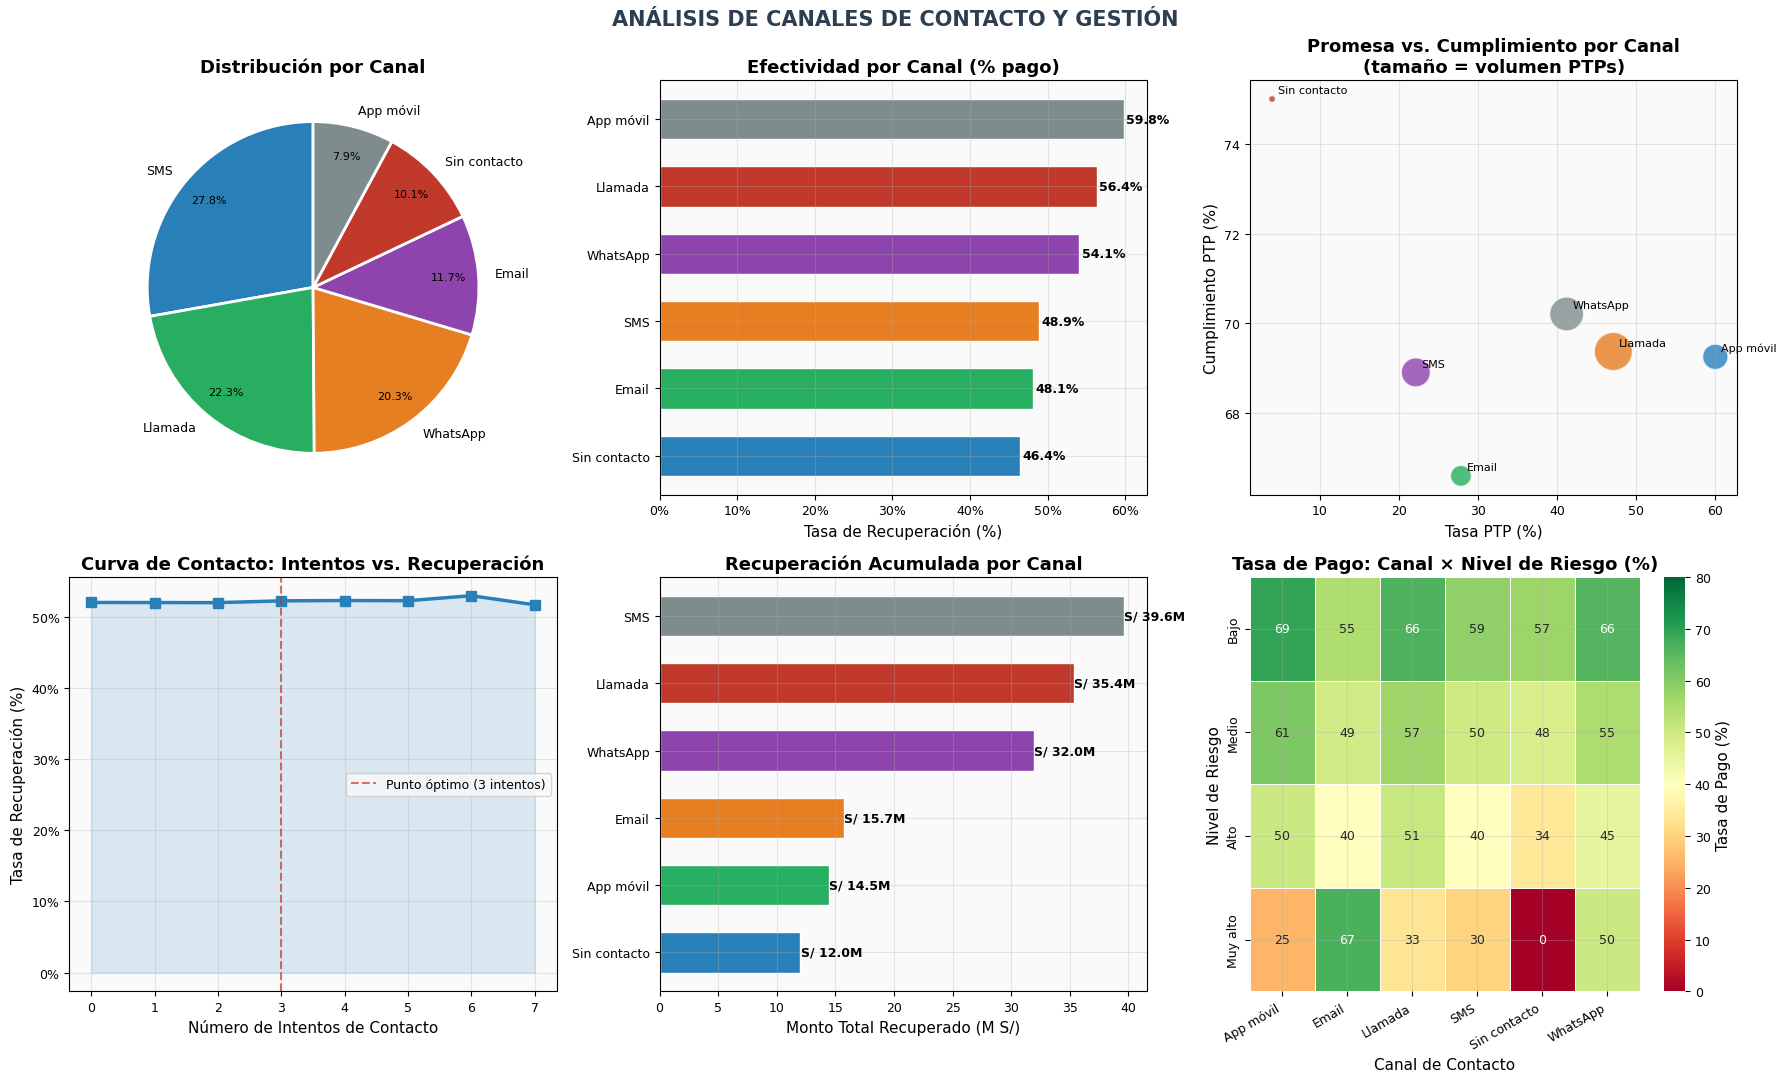

  → fig02_analisis_canales.png guardada


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ANÁLISIS DE CANALES DE CONTACTO Y GESTIÓN",
             fontsize=15, fontweight="bold", color=PALETTE["dark"])

canal_colors = [PALETTE["azul"], PALETTE["verde"], PALETTE["naranja"],
                PALETTE["morado"], PALETTE["rojo"], PALETTE["gris"]]

# ── Distribución de clientes por canal
ax = axes[0, 0]
canal_n = df["canal_contacto"].value_counts()
wedges, texts, autotexts = ax.pie(
    canal_n.values, labels=canal_n.index,
    colors=canal_colors[:len(canal_n)],
    autopct="%1.1f%%", startangle=90,
    pctdistance=0.82, wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts: t.set_fontsize(8)
ax.set_title("Distribución por Canal", fontweight="bold")

# ── Tasa de recuperación por canal
ax = axes[0, 1]
c_order = canal_stats.sort_values("tasa_pago", ascending=True)
ax.barh(c_order["canal_contacto"], c_order["tasa_pago"] * 100,
        color=canal_colors[:len(c_order)], edgecolor="white", height=0.6)
for i, (_, row) in enumerate(c_order.iterrows()):
    ax.text(row["tasa_pago"] * 100 + 0.3, i, f"{row['tasa_pago']:.1%}",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Tasa de Recuperación (%)")
ax.set_title("Efectividad por Canal (% pago)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Tasa PTP vs Cumplimiento
ax = axes[0, 2]
canal_ptp = df[df["ptp_flag"] == 1].groupby("canal_contacto").agg(
    ptp_cnt      = ("ptp_flag", "count"),
    cumpl_ptp    = ("pagado", "mean")
).reset_index()
scatter = ax.scatter(
    canal_stats.set_index("canal_contacto").loc[canal_ptp["canal_contacto"], "tasa_ptp"] * 100,
    canal_ptp["cumpl_ptp"] * 100,
    s=canal_ptp["ptp_cnt"] / 2, alpha=0.8,
    c=canal_colors[:len(canal_ptp)], edgecolors="white", linewidths=1.5
)
for i, row in canal_ptp.iterrows():
    ax.annotate(row["canal_contacto"],
                xy=(canal_stats[canal_stats["canal_contacto"]==row["canal_contacto"]]["tasa_ptp"].values[0]*100,
                    row["cumpl_ptp"]*100),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Tasa PTP (%)")
ax.set_ylabel("Cumplimiento PTP (%)")
ax.set_title("Promesa vs. Cumplimiento por Canal\n(tamaño = volumen PTPs)", fontweight="bold")

# ── Intentos de contacto vs tasa de pago (curva de contacto)
ax = axes[1, 0]
contact_curve = df.groupby("intentos_contacto")["pagado"].agg(["mean", "count"]).reset_index()
contact_curve.columns = ["intentos", "tasa", "n"]
ax.plot(contact_curve["intentos"], contact_curve["tasa"] * 100,
        color=PALETTE["azul"], lw=2.5, marker="s", ms=7)
ax.fill_between(contact_curve["intentos"], contact_curve["tasa"] * 100,
                alpha=0.15, color=PALETTE["azul"])
ax.axvline(x=3, color=PALETTE["rojo"], linestyle="--", alpha=0.7, label="Punto óptimo (3 intentos)")
ax.set_xlabel("Número de Intentos de Contacto")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Curva de Contacto: Intentos vs. Recuperación", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Monto recuperado por canal (acumulado)
ax = axes[1, 1]
canal_monto = canal_stats.sort_values("monto_rec_sum", ascending=True)
ax.barh(canal_monto["canal_contacto"], canal_monto["monto_rec_sum"] / 1e6,
        color=canal_colors[:len(canal_monto)], edgecolor="white", height=0.6)
for i, (_, row) in enumerate(canal_monto.iterrows()):
    ax.text(row["monto_rec_sum"] / 1e6 + 0.01, i,
            f"S/ {row['monto_rec_sum']/1e6:.1f}M",
            va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Monto Total Recuperado (M S/)")
ax.set_title("Recuperación Acumulada por Canal", fontweight="bold")

# ── Heatmap: Canal × Riesgo → Tasa de pago
ax = axes[1, 2]
pivot = df.pivot_table(values="pagado", index="riesgo", columns="canal_contacto", aggfunc="mean")
pivot = pivot.reindex(["Bajo", "Medio", "Alto", "Muy alto"])
sns.heatmap(pivot * 100, ax=ax, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=80, linewidths=0.5, annot_kws={"size": 9},
            cbar_kws={"label": "Tasa de Pago (%)"})
ax.set_title("Tasa de Pago: Canal × Nivel de Riesgo (%)", fontweight="bold")
ax.set_xlabel("Canal de Contacto")
ax.set_ylabel("Nivel de Riesgo")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("fig02_analisis_canales.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig02_analisis_canales.png guardada")


#### 6.Segmentacion de Cartera por Score y Comportamiento de Pago

In [ ]:
# Crear deciles de score
df["decil_score"] = pd.qcut(df["score_interno"], q=10, labels=False) + 1

decil_stats = df.groupby("decil_score").agg(
    n             = ("pagado", "count"),
    tasa_rec      = ("pagado", "mean"),
    score_med     = ("score_interno", "median"),
    deuda_med     = ("monto_deuda", "median"),
    monto_rec_sum = ("monto_recuperado", "sum"),
).reset_index()
decil_stats["monto_rec_cum"] = decil_stats["monto_rec_sum"].cumsum()
decil_stats["pct_rec_cum"]   = decil_stats["monto_rec_cum"] / decil_stats["monto_rec_sum"].sum()

print("\n  Decil | Score Med. | Tasa Rec. | Monto Rec. Acum. | % Acum. Cartera")
print("  " + "─" * 65)
for _, row in decil_stats.iterrows():
    bar = "█" * int(row["tasa_rec"] * 20)
    print(f"  D{int(row['decil_score']):02d}   | {int(row['score_med']):>10} | "
          f"{row['tasa_rec']:>9.1%} | S/ {row['monto_rec_cum']/1e6:>10.1f}M | "
          f"{row['pct_rec_cum']:>8.1%}  {bar}")


[PASO 6] Segmentando cartera por score y comportamiento de pago...

  Decil | Score Med. | Tasa Rec. | Monto Rec. Acum. | % Acum. Cartera
  ─────────────────────────────────────────────────────────────────
  D01   |        497 |     42.5% | S/       14.7M |     9.9%  ████████
  D02   |        544 |     45.1% | S/       28.3M |    19.0%  █████████
  D03   |        571 |     48.2% | S/       43.5M |    29.2%  █████████
  D04   |        592 |     50.7% | S/       59.0M |    39.6%  ██████████
  D05   |        609 |     53.8% | S/       75.4M |    50.5%  ██████████
  D06   |        625 |     52.7% | S/       89.7M |    60.2%  ██████████
  D07   |        641 |     52.6% | S/      104.7M |    70.2%  ██████████
  D08   |        659 |     58.9% | S/      120.5M |    80.8%  ███████████
  D09   |        681 |     55.3% | S/      133.4M |    89.4%  ███████████
  D10   |        715 |     62.0% | S/      149.2M |   100.0%  ████████████


#### 7.Segmentacion y Concentracion de Cartera

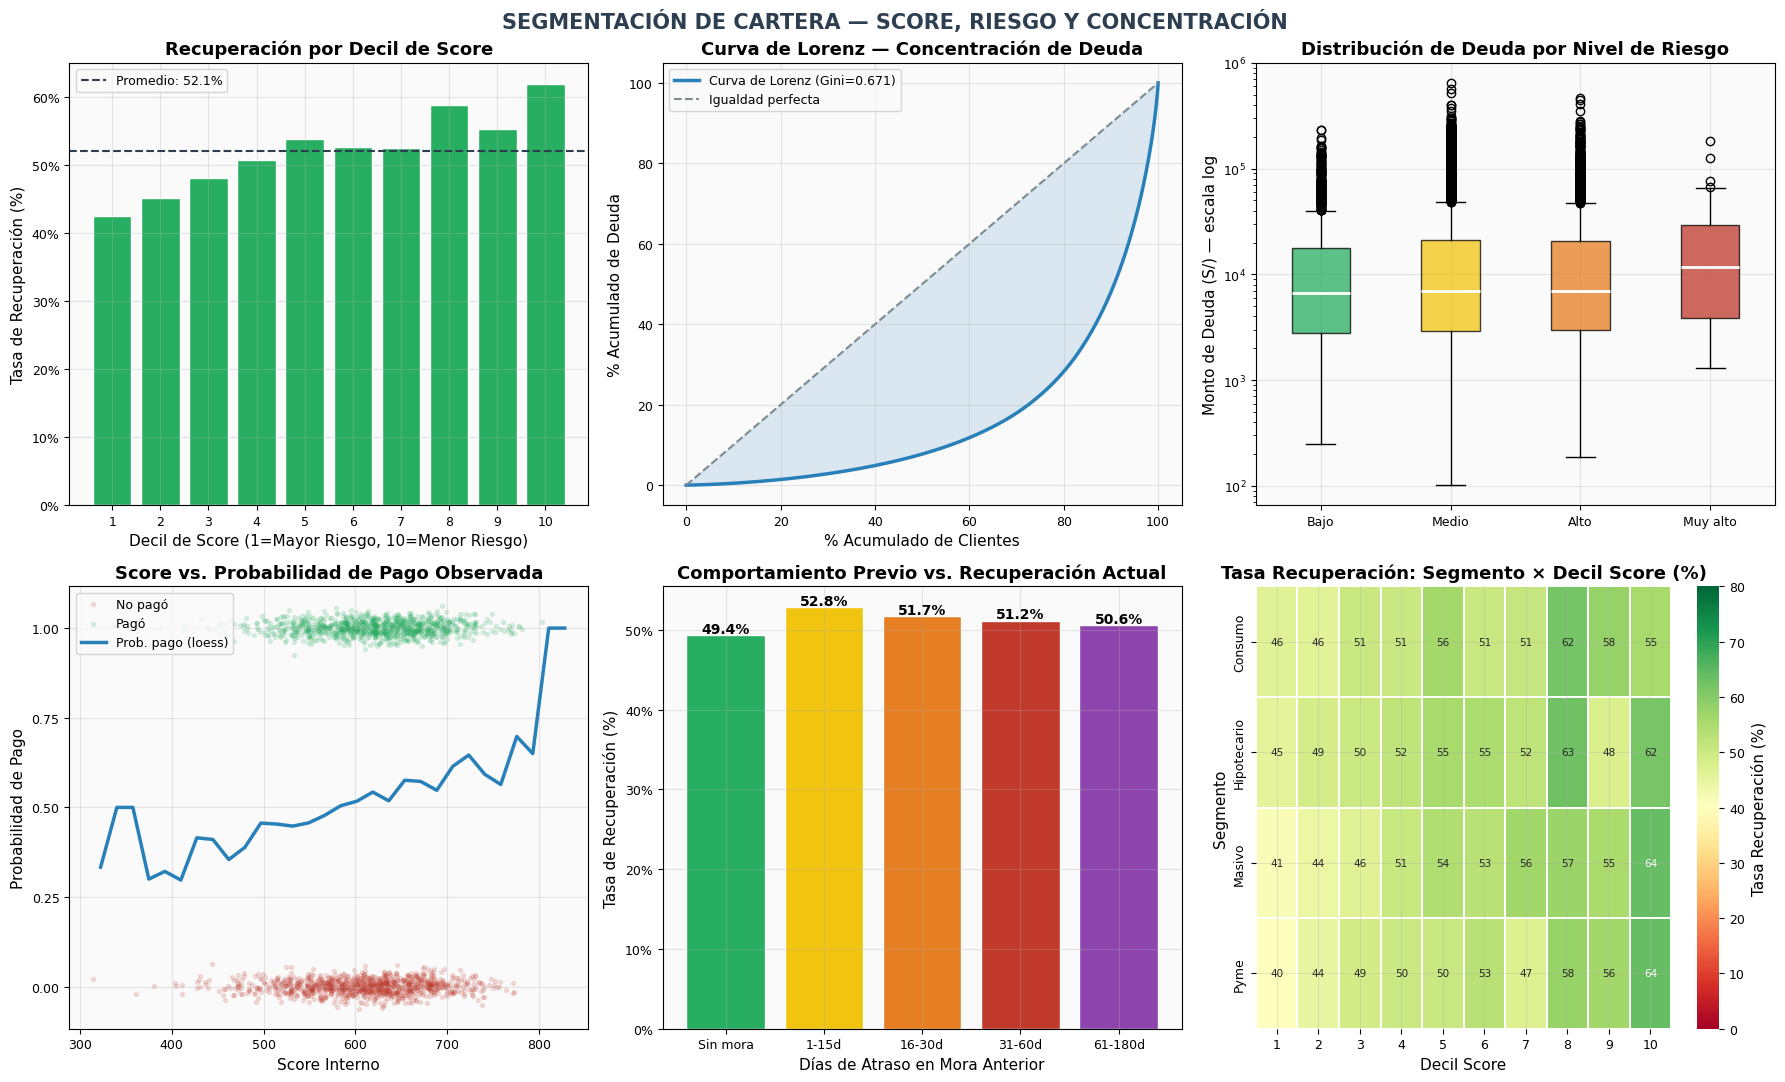

  → fig03_segmentacion_cartera.png guardada


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("SEGMENTACIÓN DE CARTERA — SCORE, RIESGO Y CONCENTRACIÓN",
             fontsize=15, fontweight="bold", color=PALETTE["dark"])

# ── Tasa recuperación por decil (waterfall style)
ax = axes[0, 0]
colors_dec = [PALETTE["rojo"] if t < 0.28 else PALETTE["naranja"] if t < 0.42 else PALETTE["verde"]
              for t in decil_stats["tasa_rec"]]
ax.bar(decil_stats["decil_score"], decil_stats["tasa_rec"] * 100,
       color=colors_dec, edgecolor="white")
ax.axhline(y=tasa_recuperacion_global * 100, color=PALETTE["dark"],
           linestyle="--", lw=1.5, label=f"Promedio: {tasa_recuperacion_global:.1%}")
ax.set_xlabel("Decil de Score (1=Mayor Riesgo, 10=Menor Riesgo)")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Recuperación por Decil de Score", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xticks(range(1, 11))

# ── Curva de Lorenz de la deuda
ax = axes[0, 1]
sorted_deuda = np.sort(df["monto_deuda"].values)
cum_deuda    = np.cumsum(sorted_deuda) / sorted_deuda.sum()
cum_clientes = np.linspace(0, 1, len(sorted_deuda))
gini         = 1 - 2 * np.trapezoid(cum_deuda, cum_clientes)
ax.plot(cum_clientes * 100, cum_deuda * 100, color=PALETTE["azul"],
        lw=2.5, label=f"Curva de Lorenz (Gini={gini:.3f})")
ax.plot([0, 100], [0, 100], color=PALETTE["gris"], linestyle="--",
        lw=1.5, label="Igualdad perfecta")
ax.fill_between(cum_clientes * 100, cum_clientes * 100, cum_deuda * 100,
                alpha=0.15, color=PALETTE["azul"])
ax.set_xlabel("% Acumulado de Clientes")
ax.set_ylabel("% Acumulado de Deuda")
ax.set_title("Curva de Lorenz — Concentración de Deuda", fontweight="bold")
ax.legend()

# ── Box plot: deuda por nivel de riesgo
ax = axes[0, 2]
riesgo_order = ["Bajo", "Medio", "Alto", "Muy alto"]
data_box     = [df[df["riesgo"] == r]["monto_deuda"].values for r in riesgo_order]
bp = ax.boxplot(data_box, labels=riesgo_order, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2))
for patch, color in zip(bp["boxes"], [PALETTE["verde"], PALETTE["amarillo"],
                                       PALETTE["naranja"], PALETTE["rojo"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_yscale("log")
ax.set_ylabel("Monto de Deuda (S/) — escala log")
ax.set_title("Distribución de Deuda por Nivel de Riesgo", fontweight="bold")

# ── Score vs. probabilidad de pago (scatter con regresión)
ax = axes[1, 0]
sample = df.sample(2000, random_state=42)
ax.scatter(sample[sample["pagado"]==0]["score_interno"],
           np.random.normal(0, 0.02, (sample["pagado"]==0).sum()),
           alpha=0.15, color=PALETTE["rojo"], s=8, label="No pagó")
ax.scatter(sample[sample["pagado"]==1]["score_interno"],
           np.random.normal(1, 0.02, (sample["pagado"]==1).sum()),
           alpha=0.15, color=PALETTE["verde"], s=8, label="Pagó")
# suavizado por bins
bins_score = pd.cut(df["score_interno"], bins=30)
prob_bins  = df.groupby(bins_score)["pagado"].mean()
mid_bins   = [(b.left + b.right) / 2 for b in prob_bins.index]
ax.plot(mid_bins, prob_bins.values, color=PALETTE["azul"], lw=2.5, label="Prob. pago (loess)")
ax.set_xlabel("Score Interno")
ax.set_ylabel("Probabilidad de Pago")
ax.set_title("Score vs. Probabilidad de Pago Observada", fontweight="bold")
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper left")

# ── Análisis RFM simplificado: mora anterior vs tasa actual
ax = axes[1, 1]
df["rango_mora_ant"] = pd.cut(df["dias_atraso_ant"],
                               bins=[-1, 0, 15, 30, 60, 180],
                               labels=["Sin mora", "1-15d", "16-30d", "31-60d", "61-180d"])
mora_rec = df.groupby("rango_mora_ant")["pagado"].mean()
bar_colors = [PALETTE["verde"], PALETTE["amarillo"], PALETTE["naranja"],
              PALETTE["rojo"], PALETTE["morado"]][:len(mora_rec)]
bars = ax.bar(mora_rec.index, mora_rec.values * 100, color=bar_colors, edgecolor="white")
for bar, val in zip(bars, mora_rec.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Días de Atraso en Mora Anterior")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Comportamiento Previo vs. Recuperación Actual", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Mapa de calor: segmento × decil → tasa de recuperación
ax = axes[1, 2]
pivot2 = df.pivot_table(values="pagado", index="segmento",
                         columns="decil_score", aggfunc="mean")
sns.heatmap(pivot2 * 100, ax=ax, annot=True, fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=80, linewidths=0.3,
            annot_kws={"size": 7.5},
            cbar_kws={"label": "Tasa Recuperación (%)"})
ax.set_title("Tasa Recuperación: Segmento × Decil Score (%)", fontweight="bold")
ax.set_xlabel("Decil Score")
ax.set_ylabel("Segmento")

plt.tight_layout()
plt.savefig("fig03_segmentacion_cartera.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig03_segmentacion_cartera.png guardada")

#### 8.Factores de Recuperacion / Correlacion

In [15]:
num_features = [
    "edad", "monto_deuda", "antiguedad_credito", "num_cuotas_pend",
    "tasa_interes", "veces_en_mora_12m", "dias_atraso_ant",
    "pagos_al_dia_12m", "score_interno", "intentos_contacto", "ptp_flag"
]

corr_target = df[num_features + ["pagado"]].corr()["pagado"].drop("pagado").sort_values()
print("\n  Correlaciones con variable objetivo (pago efectivo):")
print("  " + "─" * 50)
for var, corr in corr_target.items():
    bar = ("▼" if corr < 0 else "▲") + "█" * int(abs(corr) * 20)
    print(f"  {var:<25} {corr:>+7.3f}  {bar}")

# Test Chi-cuadrado para variables categóricas
print("\n  Test Chi-Cuadrado (variables categóricas vs. pago):")
print("  " + "─" * 55)
for cat_var in ["canal_contacto", "riesgo", "segmento", "region"]:
    ct   = pd.crosstab(df[cat_var], df["pagado"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig  = "✓ Significativo" if p < 0.05 else "✗ No significativo"
    print(f"  {cat_var:<20} chi2={chi2:>10.1f}  p={p:.2e}  {sig}")


  Correlaciones con variable objetivo (pago efectivo):
  ──────────────────────────────────────────────────
  veces_en_mora_12m          -0.095  ▼█
  monto_deuda                -0.012  ▼
  dias_atraso_ant            -0.011  ▼
  num_cuotas_pend            -0.006  ▼
  intentos_contacto          +0.002  ▲
  edad                       +0.008  ▲
  tasa_interes               +0.009  ▲
  antiguedad_credito         +0.034  ▲
  pagos_al_dia_12m           +0.099  ▲█
  score_interno              +0.109  ▲██
  ptp_flag                   +0.243  ▲████

  Test Chi-Cuadrado (variables categóricas vs. pago):
  ───────────────────────────────────────────────────────
  canal_contacto       chi2=     104.7  p=5.36e-21  ✓ Significativo
  riesgo               chi2=     129.7  p=6.26e-28  ✓ Significativo
  segmento             chi2=       2.0  p=5.64e-01  ✗ No significativo
  region               chi2=       2.8  p=7.27e-01  ✗ No significativo


#### 9. Modelo predictivo para evaluar la propension de Pago

In [16]:
# Preparar features
cat_cols = ["genero", "region", "segmento", "canal_contacto", "riesgo"]
df_model  = df.copy()
le_dict   = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col])
    le_dict[col] = le

feature_cols = num_features + [c + "_enc" for c in cat_cols]
X = df_model[feature_cols].values
y = df_model["pagado"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

modelos = {
    "Regresión Logística": LogisticRegression(max_iter=500, C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                                       learning_rate=0.1, random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    X_tr = X_train_s if nombre == "Regresión Logística" else X_train
    X_te = X_test_s  if nombre == "Regresión Logística" else X_test
    modelo.fit(X_tr, y_train)
    proba  = modelo.predict_proba(X_te)[:, 1]
    pred   = modelo.predict(X_te)
    auc    = roc_auc_score(y_test, proba)
    ap     = average_precision_score(y_test, proba)
    cv_auc = cross_val_score(modelo, X_tr, y_train, cv=5, scoring="roc_auc",
                              n_jobs=-1 if nombre != "Regresión Logística" else 1).mean()
    resultados[nombre] = {
        "modelo": modelo, "proba_test": proba, "pred_test": pred,
        "auc": auc, "ap": ap, "cv_auc": cv_auc
    }
    report = classification_report(y_test, pred, output_dict=True)
    print(f"\n  ── {nombre} ──")
    print(f"     AUC-ROC : {auc:.4f}  |  CV AUC (5-fold): {cv_auc:.4f}")
    print(f"     Avg. Precision: {ap:.4f}")
    print(f"     Precision (1): {report['1']['precision']:.3f} | "
          f"Recall (1): {report['1']['recall']:.3f} | "
          f"F1 (1): {report['1']['f1-score']:.3f}")

# Mejor modelo
best_name  = max(resultados, key=lambda k: resultados[k]["auc"])
best_model = resultados[best_name]["modelo"]
print(f"\n  ✓ Mejor modelo: {best_name}  (AUC = {resultados[best_name]['auc']:.4f})")

# Importancia de variables (Gradient Boosting)
gb_model    = resultados["Gradient Boosting"]["modelo"]
importances = gb_model.feature_importances_
feat_imp    = pd.Series(importances, index=feature_cols).sort_values(ascending=False).head(15)

print("\n  Top 10 variables más importantes (Gradient Boosting):")
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    bar = "█" * int(imp * 100)
    print(f"  {i:>2}. {feat:<30}  {imp:.4f}  {bar}")



  ── Regresión Logística ──
     AUC-ROC : 0.6541  |  CV AUC (5-fold): 0.6380
     Avg. Precision: 0.6720
     Precision (1): 0.665 | Recall (1): 0.515 | F1 (1): 0.581

  ── Random Forest ──
     AUC-ROC : 0.6494  |  CV AUC (5-fold): 0.6331
     Avg. Precision: 0.6600
     Precision (1): 0.661 | Recall (1): 0.515 | F1 (1): 0.579

  ── Gradient Boosting ──
     AUC-ROC : 0.6477  |  CV AUC (5-fold): 0.6242
     Avg. Precision: 0.6599
     Precision (1): 0.652 | Recall (1): 0.548 | F1 (1): 0.596

  ✓ Mejor modelo: Regresión Logística  (AUC = 0.6541)

  Top 10 variables más importantes (Gradient Boosting):
   1. ptp_flag                        0.4094  ████████████████████████████████████████
   2. score_interno                   0.1357  █████████████
   3. monto_deuda                     0.1210  ████████████
   4. antiguedad_credito              0.0564  █████
   5. edad                            0.0552  █████
   6. dias_atraso_ant                 0.0550  █████
   7. num_cuotas_pend      

#### 10. Evaluacion de Modelos Generado

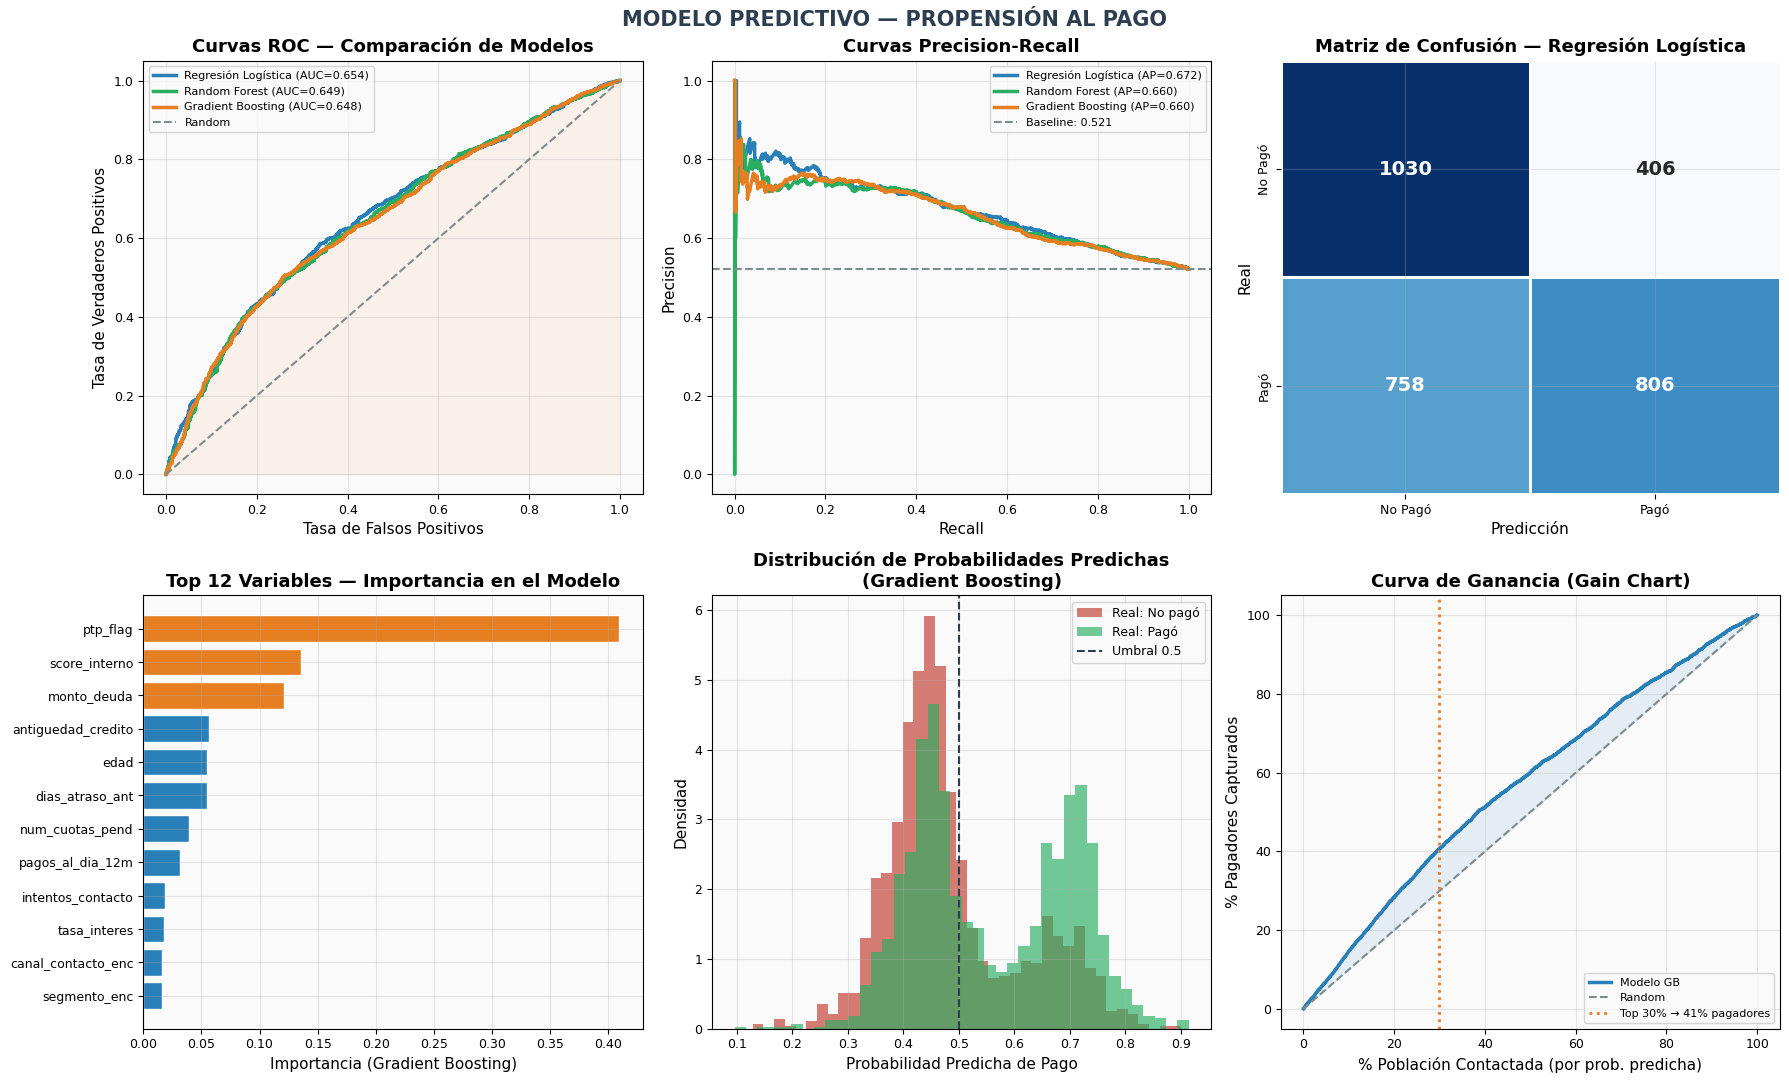

  → fig04_modelos_predictivos.png guardada


In [18]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("MODELO PREDICTIVO — PROPENSIÓN AL PAGO",
             fontsize=15, fontweight="bold", color=PALETTE["dark"])

model_colors = [PALETTE["azul"], PALETTE["verde"], PALETTE["naranja"]]

# ── Curvas ROC
ax = axes[0, 0]
for (nombre, res), color in zip(resultados.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, res["proba_test"])
    ax.plot(fpr, tpr, lw=2.5, color=color,
            label=f"{nombre} (AUC={res['auc']:.3f})")
ax.plot([0, 1], [0, 1], color=PALETTE["gris"], linestyle="--", lw=1.5, label="Random")
ax.fill_between(*roc_curve(y_test, resultados["Gradient Boosting"]["proba_test"])[:2],
                alpha=0.08, color=PALETTE["naranja"])
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Comparación de Modelos", fontweight="bold")
ax.legend(fontsize=8)

# ── Curvas Precision-Recall
ax = axes[0, 1]
for (nombre, res), color in zip(resultados.items(), model_colors):
    prec, rec, _ = precision_recall_curve(y_test, res["proba_test"])
    ax.plot(rec, prec, lw=2.5, color=color,
            label=f"{nombre} (AP={res['ap']:.3f})")
ax.axhline(y=y_test.mean(), color=PALETTE["gris"], linestyle="--",
           lw=1.5, label=f"Baseline: {y_test.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall", fontweight="bold")
ax.legend(fontsize=8)

# ── Matriz de confusión (mejor modelo)
ax = axes[0, 2]
best_pred = resultados[best_name]["pred_test"]
cm        = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Pagó", "Pagó"],
            yticklabels=["No Pagó", "Pagó"],
            linewidths=1, cbar=False, annot_kws={"size": 14, "weight": "bold"})
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de Confusión — {best_name}", fontweight="bold")

# ── Importancia de variables (top 15)
ax = axes[1, 0]
feat_imp_plot = feat_imp.head(12)
colors_imp    = [PALETTE["naranja"] if imp > feat_imp_plot.quantile(0.75) else PALETTE["azul"]
                 for imp in feat_imp_plot.values]
ax.barh(feat_imp_plot.index[::-1], feat_imp_plot.values[::-1],
        color=colors_imp[::-1], edgecolor="white")
ax.set_xlabel("Importancia (Gradient Boosting)")
ax.set_title("Top 12 Variables — Importancia en el Modelo", fontweight="bold")

# ── Distribución de probabilidades predichas
ax = axes[1, 1]
gb_proba = resultados["Gradient Boosting"]["proba_test"]
ax.hist(gb_proba[y_test == 0], bins=40, alpha=0.65, density=True,
        color=PALETTE["rojo"], label="Real: No pagó")
ax.hist(gb_proba[y_test == 1], bins=40, alpha=0.65, density=True,
        color=PALETTE["verde"], label="Real: Pagó")
ax.axvline(x=0.5, color=PALETTE["dark"], linestyle="--", lw=1.5, label="Umbral 0.5")
ax.set_xlabel("Probabilidad Predicha de Pago")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de Probabilidades Predichas\n(Gradient Boosting)", fontweight="bold")
ax.legend()

# ── Curva de lift / ganancia
ax = axes[1, 2]
gb_proba_sorted = np.sort(gb_proba)[::-1]
order           = np.argsort(gb_proba)[::-1]
gains           = np.cumsum(y_test[order]) / y_test.sum()
lift_vals        = gains / (np.arange(1, len(y_test) + 1) / len(y_test))
pct_population  = np.arange(1, len(y_test) + 1) / len(y_test) * 100
ax.plot(pct_population, gains * 100, color=PALETTE["azul"], lw=2.5, label="Modelo GB")
ax.plot([0, 100], [0, 100], color=PALETTE["gris"], linestyle="--", lw=1.5, label="Random")
ax.fill_between(pct_population, pct_population, gains * 100, alpha=0.1, color=PALETTE["azul"])
ax.axvline(x=30, color=PALETTE["naranja"], linestyle=":", lw=2,
           label=f"Top 30% → {gains[int(0.3*len(gains))]:.0%} pagadores")
ax.set_xlabel("% Población Contactada (por prob. predicha)")
ax.set_ylabel("% Pagadores Capturados")
ax.set_title("Curva de Ganancia (Gain Chart)", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig04_modelos_predictivos.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig04_modelos_predictivos.png guardada")

#### 11. Priorizacion para las llamadas y canales optimos recomendados

In [19]:
# Asignar probabilidad predicha (mejor modelo)
gb_all    = resultados["Gradient Boosting"]["modelo"]
X_all     = df_model[feature_cols].values
df["prob_pago_pred"] = gb_all.predict_proba(X_all)[:, 1]

# Segmentación estratégica
def segmento_estrategico(row):
    if row["prob_pago_pred"] >= 0.65 and row["monto_deuda"] >= 5000:
        return "A — Prioritario Alto Valor"
    elif row["prob_pago_pred"] >= 0.65:
        return "B — Prioritario Masivo"
    elif row["prob_pago_pred"] >= 0.40:
        return "C — Potencial Medio"
    elif row["prob_pago_pred"] >= 0.20:
        return "D — Bajo Potencial"
    else:
        return "E — Recuperación Tardía"

df["segmento_estrategico"] = df.apply(segmento_estrategico, axis=1)

estrat_stats = df.groupby("segmento_estrategico").agg(
    n_clientes    = ("pagado", "count"),
    prob_media    = ("prob_pago_pred", "mean"),
    deuda_total   = ("monto_deuda", "sum"),
    rec_potencial = ("monto_deuda", lambda x: x[df.loc[x.index, "prob_pago_pred"] >= 0.5].sum()),
    tasa_real     = ("pagado", "mean"),
).reset_index().sort_values("segmento_estrategico")

estrat_stats["deuda_total_M"]  = estrat_stats["deuda_total"] / 1e6
estrat_stats["rec_pot_M"]      = estrat_stats["rec_potencial"] / 1e6
estrat_stats["pct_cartera"]    = estrat_stats["deuda_total"] / estrat_stats["deuda_total"].sum()

print("\n  Segmento Estratégico         | N       | Prob. Med. | Deuda Total | % Cartera | Tasa Real")
print("  " + "─" * 90)
for _, r in estrat_stats.iterrows():
    print(f"  {r['segmento_estrategico']:<30} | {r['n_clientes']:>7,} | "
          f"{r['prob_media']:>10.1%} | S/ {r['deuda_total_M']:>6.1f}M   | "
          f"{r['pct_cartera']:>9.1%} | {r['tasa_real']:>9.1%}")

# Canalización óptima recomendada
canal_optimo = {
    "A — Prioritario Alto Valor":  "Llamada personalizada (ejecutivo senior)",
    "B — Prioritario Masivo":      "WhatsApp + SMS con link de pago",
    "C — Potencial Medio":         "SMS + App móvil (auto-gestión)",
    "D — Bajo Potencial":          "Email + SMS recordatorio",
    "E — Recuperación Tardía":     "Negociación / Refinanciamiento",
}
print("\n  Canal recomendado por segmento estratégico:")
for seg, canal in canal_optimo.items():
    print(f"  {seg:<35} → {canal}")


  Segmento Estratégico         | N       | Prob. Med. | Deuda Total | % Cartera | Tasa Real
  ──────────────────────────────────────────────────────────────────────────────────────────
  A — Prioritario Alto Valor     |   2,287 |      71.8% | S/   71.9M   |     23.4% |     76.7%
  B — Prioritario Masivo         |   1,589 |      72.1% | S/    4.1M   |      1.3% |     77.0%
  C — Potencial Medio            |   8,496 |      48.5% | S/  157.9M   |     51.4% |     49.7%
  D — Bajo Potencial             |   2,564 |      35.7% | S/   69.1M   |     22.5% |     24.1%
  E — Recuperación Tardía        |      64 |      15.6% | S/    4.5M   |      1.5% |      7.8%

  Canal recomendado por segmento estratégico:
  A — Prioritario Alto Valor          → Llamada personalizada (ejecutivo senior)
  B — Prioritario Masivo              → WhatsApp + SMS con link de pago
  C — Potencial Medio                 → SMS + App móvil (auto-gestión)
  D — Bajo Potencial                  → Email + SMS recordatorio
  E

#### 12.Estrategia de priorizacion

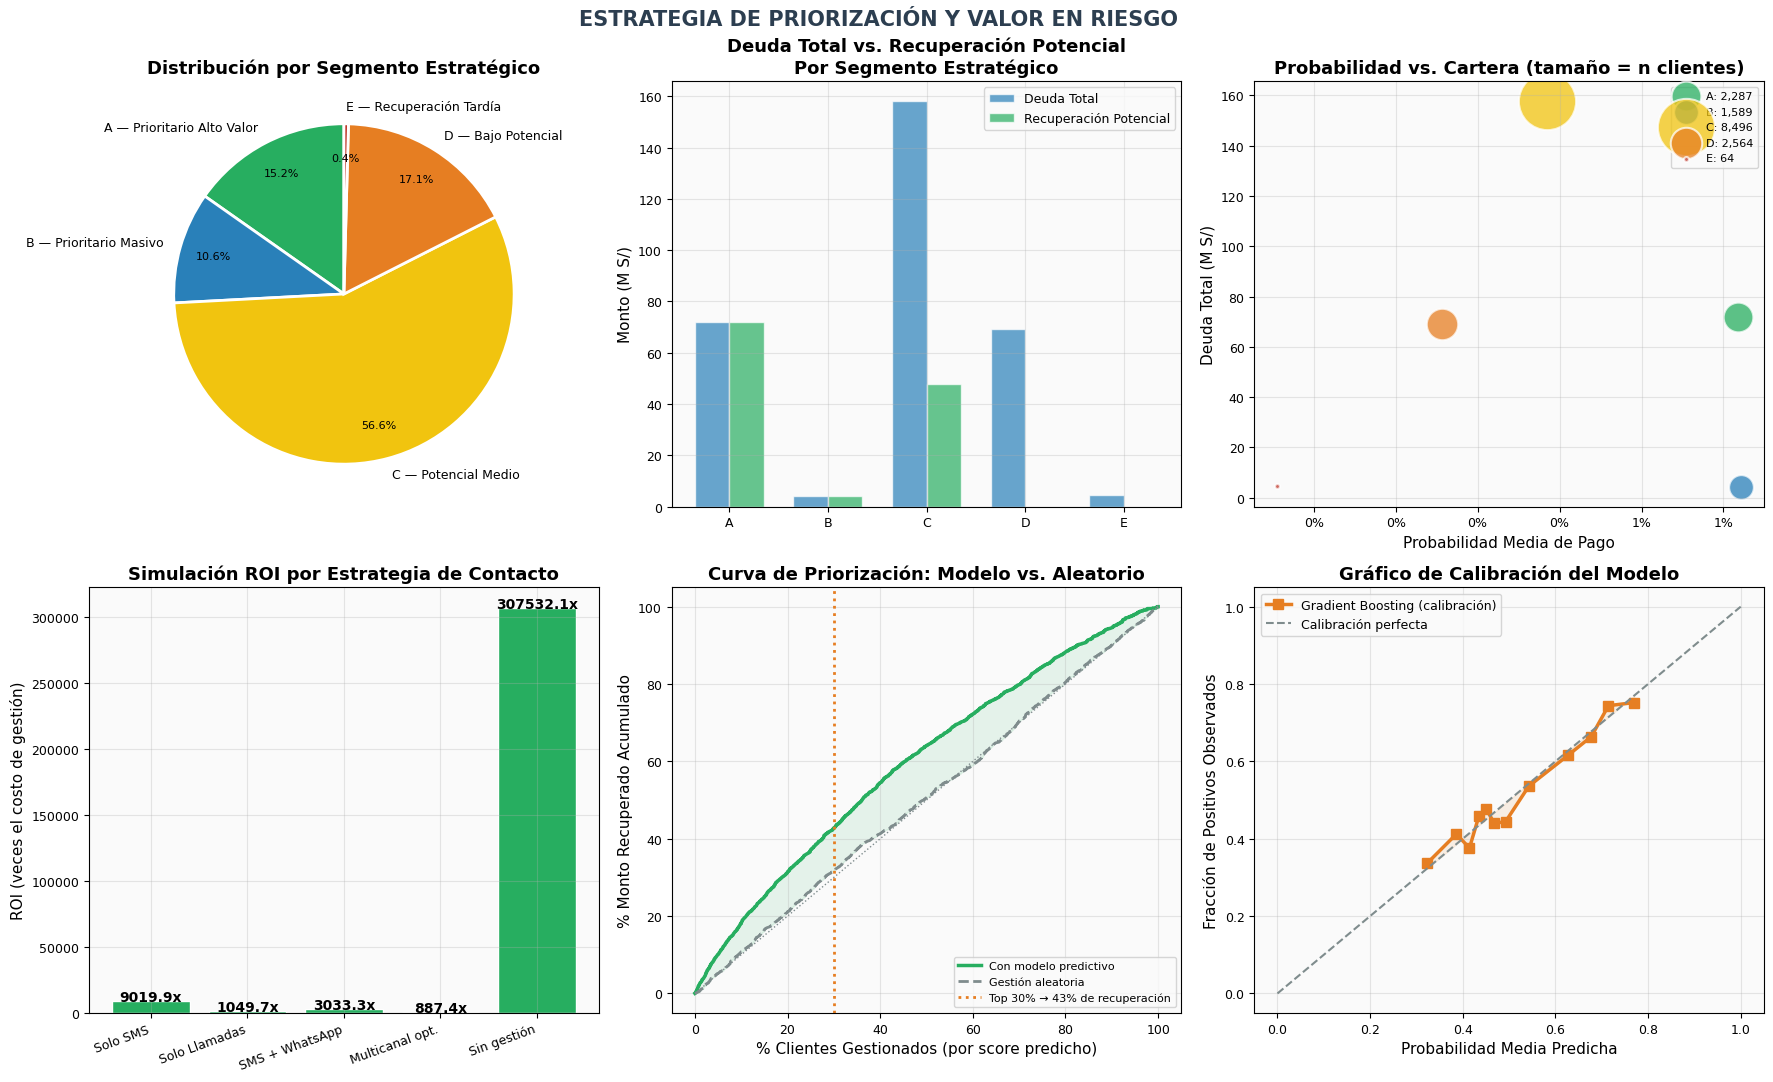

  → fig05_estrategia_priorizacion.png guardada


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ESTRATEGIA DE PRIORIZACIÓN Y VALOR EN RIESGO",
             fontsize=15, fontweight="bold", color=PALETTE["dark"])

seg_colors_e = [PALETTE["verde"], PALETTE["azul"], PALETTE["amarillo"],
                PALETTE["naranja"], PALETTE["rojo"]]

# ── Distribución de clientes por segmento estratégico
ax = axes[0, 0]
wedges, texts, autotexts = ax.pie(
    estrat_stats["n_clientes"], labels=estrat_stats["segmento_estrategico"],
    colors=seg_colors_e, autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.8
)
for t in autotexts: t.set_fontsize(8)
ax.set_title("Distribución por Segmento Estratégico", fontweight="bold")

# ── Deuda total vs. Recuperación potencial
ax = axes[0, 1]
x_pos = np.arange(len(estrat_stats))
w     = 0.35
ax.bar(x_pos - w/2, estrat_stats["deuda_total_M"],  width=w, color=PALETTE["azul"],
       alpha=0.7, label="Deuda Total", edgecolor="white")
ax.bar(x_pos + w/2, estrat_stats["rec_pot_M"],      width=w, color=PALETTE["verde"],
       alpha=0.7, label="Recuperación Potencial", edgecolor="white")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.split(" — ")[0] for s in estrat_stats["segmento_estrategico"]],
                   rotation=0, fontsize=9)
ax.set_ylabel("Monto (M S/)")
ax.set_title("Deuda Total vs. Recuperación Potencial\nPor Segmento Estratégico", fontweight="bold")
ax.legend()

# ── Bubble chart: prob. predicha vs. monto deuda → tamaño = n clientes
ax = axes[0, 2]
for i, (_, row) in enumerate(estrat_stats.iterrows()):
    ax.scatter(row["prob_media"], row["deuda_total_M"],
               s=row["n_clientes"] / 5, alpha=0.75,
               color=seg_colors_e[i], edgecolors="white", linewidths=1.5,
               label=f"{row['segmento_estrategico'].split(' — ')[0]}: {row['n_clientes']:,}")
ax.set_xlabel("Probabilidad Media de Pago")
ax.set_ylabel("Deuda Total (M S/)")
ax.set_title("Probabilidad vs. Cartera (tamaño = n clientes)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(fontsize=8)

# ── Simulación de ROI por estrategia de contacto
ax = axes[1, 0]
canales_sim = ["Solo SMS", "Solo Llamadas", "SMS + WhatsApp", "Multicanal opt.", "Sin gestión"]
costos_unit = [0.5, 8.0, 2.5, 12.0, 0.0]   # S/ por cliente
rec_rate    = [0.22, 0.41, 0.37, 0.52, 0.15]  # tasa estimada
deuda_prom  = df["monto_deuda"].mean()
roi_vals    = [(r * deuda_prom - c) / max(c, 0.01) for r, c in zip(rec_rate, costos_unit)]
colors_roi  = [PALETTE["verde"] if r > 5 else PALETTE["naranja"] if r > 2 else PALETTE["rojo"]
               for r in roi_vals]
bars = ax.bar(canales_sim, roi_vals, color=colors_roi, edgecolor="white")
for bar, val in zip(bars, roi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}x", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("ROI (veces el costo de gestión)")
ax.set_title("Simulación ROI por Estrategia de Contacto", fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

# ── Curva de priorización: monto acumulado recuperado por orden de score predicho
ax = axes[1, 1]
df_sorted_pred = df.sort_values("prob_pago_pred", ascending=False).reset_index(drop=True)
df_sorted_rand = df.sample(frac=1, random_state=99).reset_index(drop=True)
cum_rec_pred = df_sorted_pred["monto_recuperado"].cumsum() / df["monto_recuperado"].sum() * 100
cum_rec_rand = df_sorted_rand["monto_recuperado"].cumsum() / df["monto_recuperado"].sum() * 100
pct_pop      = np.arange(1, N + 1) / N * 100
ax.plot(pct_pop, cum_rec_pred, color=PALETTE["verde"], lw=2.5, label="Con modelo predictivo")
ax.plot(pct_pop, cum_rec_rand, color=PALETTE["gris"],  lw=2.0, linestyle="--", label="Gestión aleatoria")
ax.plot([0, 100], [0, 100], color=PALETTE["gris"], lw=1, linestyle=":")
gain_30 = cum_rec_pred.iloc[int(0.30 * N)]
ax.axvline(x=30, color=PALETTE["naranja"], linestyle=":", lw=2,
           label=f"Top 30% → {gain_30:.0f}% de recuperación")
ax.fill_between(pct_pop, cum_rec_rand, cum_rec_pred, alpha=0.1, color=PALETTE["verde"])
ax.set_xlabel("% Clientes Gestionados (por score predicho)")
ax.set_ylabel("% Monto Recuperado Acumulado")
ax.set_title("Curva de Priorización: Modelo vs. Aleatorio", fontweight="bold")
ax.legend(fontsize=8)

# ── Score de propensión: calibration plot
ax = axes[1, 2]
fraction_pos, mean_pred = calibration_curve(
    y_test, resultados["Gradient Boosting"]["proba_test"],
    n_bins=12, strategy="quantile"
)
ax.plot(mean_pred, fraction_pos, "s-", color=PALETTE["naranja"],
        lw=2.5, ms=7, label="Gradient Boosting (calibración)")
ax.plot([0, 1], [0, 1], color=PALETTE["gris"], linestyle="--", lw=1.5, label="Calibración perfecta")
ax.fill_between(mean_pred, mean_pred, fraction_pos, alpha=0.1, color=PALETTE["naranja"])
ax.set_xlabel("Probabilidad Media Predicha")
ax.set_ylabel("Fracción de Positivos Observados")
ax.set_title("Gráfico de Calibración del Modelo", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("fig05_estrategia_priorizacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig05_estrategia_priorizacion.png guardada")

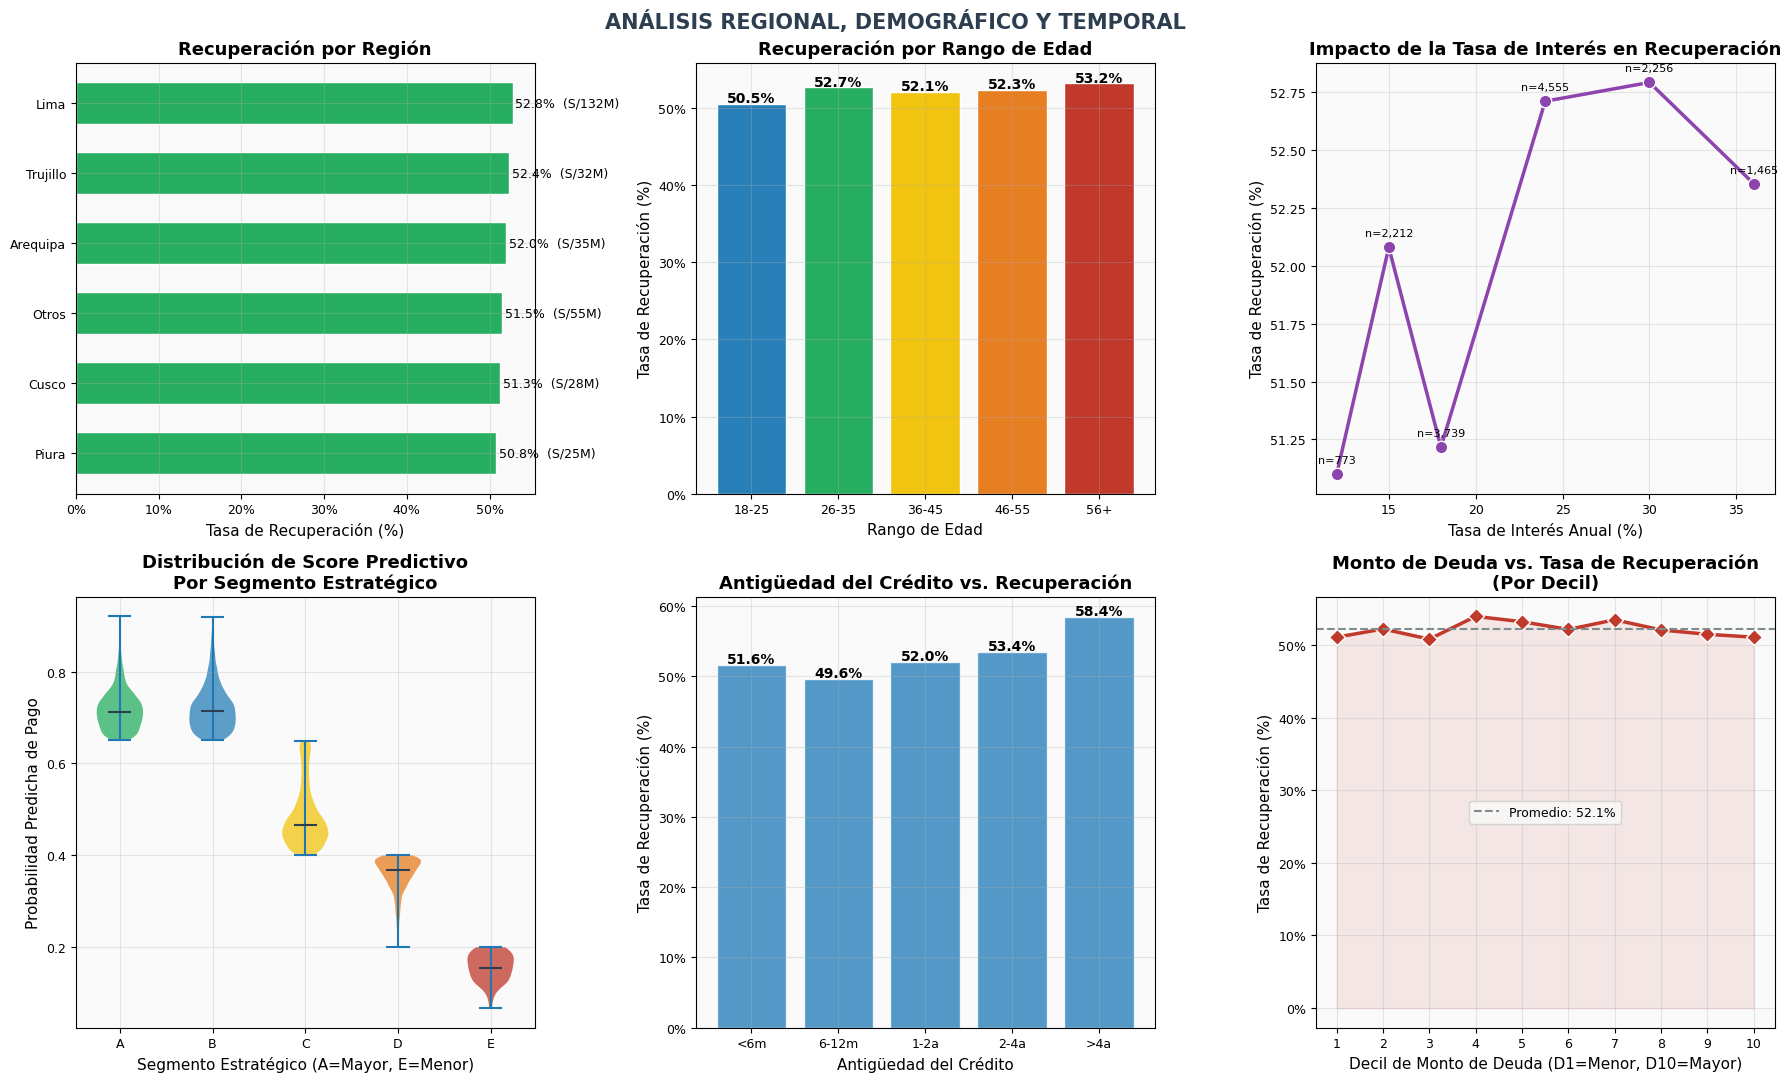

  → fig06_analisis_regional_demografico.png guardada


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("ANÁLISIS REGIONAL, DEMOGRÁFICO Y TEMPORAL",
             fontsize=15, fontweight="bold", color=PALETTE["dark"])

# ── Tasa de recuperación por región
ax = axes[0, 0]
region_rec = df.groupby("region").agg(
    tasa=("pagado", "mean"), n=("pagado", "count"),
    deuda=("monto_deuda", "sum")
).reset_index().sort_values("tasa", ascending=True)
cols_reg = [PALETTE["rojo"] if t < 0.28 else PALETTE["naranja"] if t < 0.38 else PALETTE["verde"]
            for t in region_rec["tasa"]]
ax.barh(region_rec["region"], region_rec["tasa"] * 100,
        color=cols_reg, edgecolor="white", height=0.6)
for i, (_, row) in enumerate(region_rec.iterrows()):
    ax.text(row["tasa"] * 100 + 0.3, i,
            f"{row['tasa']:.1%}  (S/{row['deuda']/1e6:.0f}M)",
            va="center", fontsize=9)
ax.set_xlabel("Tasa de Recuperación (%)")
ax.set_title("Recuperación por Región", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Tasa de recuperación por rango de edad
ax = axes[0, 1]
df["rango_edad"] = pd.cut(df["edad"],
                           bins=[17, 25, 35, 45, 55, 75],
                           labels=["18-25", "26-35", "36-45", "46-55", "56+"])
edad_rec = df.groupby("rango_edad")["pagado"].mean()
colors_e  = [PALETTE["azul"], PALETTE["verde"], PALETTE["amarillo"],
             PALETTE["naranja"], PALETTE["rojo"]]
bars = ax.bar(edad_rec.index, edad_rec.values * 100, color=colors_e, edgecolor="white")
for bar, val in zip(bars, edad_rec.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Rango de Edad")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Recuperación por Rango de Edad", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Tasa de recuperación por tasa de interés
ax = axes[0, 2]
tasa_int_rec = df.groupby("tasa_interes")["pagado"].agg(["mean", "count"]).reset_index()
ax.plot(tasa_int_rec["tasa_interes"] * 100, tasa_int_rec["mean"] * 100,
        "o-", color=PALETTE["morado"], lw=2.5, ms=9, markeredgecolor="white")
for _, row in tasa_int_rec.iterrows():
    ax.annotate(f"n={int(row['count']):,}", (row["tasa_interes"] * 100, row["mean"] * 100),
                xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
ax.set_xlabel("Tasa de Interés Anual (%)")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Impacto de la Tasa de Interés en Recuperación", fontweight="bold")

# ── Violin: distribución probabilidad predicha por segmento estratégico
ax = axes[1, 0]
seg_labels_short = ["A", "B", "C", "D", "E"]
data_viol = [df[df["segmento_estrategico"] == s]["prob_pago_pred"].values
             for s in sorted(df["segmento_estrategico"].unique())]
parts = ax.violinplot(data_viol, showmedians=True, showmeans=False)
for i, (body, color) in enumerate(zip(parts["bodies"], seg_colors_e)):
    body.set_facecolor(color); body.set_alpha(0.75)
parts["cmedians"].set_color(PALETTE["dark"])
ax.set_xticks(range(1, 6))
ax.set_xticklabels(seg_labels_short)
ax.set_ylabel("Probabilidad Predicha de Pago")
ax.set_xlabel("Segmento Estratégico (A=Mayor, E=Menor)")
ax.set_title("Distribución de Score Predictivo\nPor Segmento Estratégico", fontweight="bold")

# ── Antigüedad del crédito vs tasa de recuperación
ax = axes[1, 1]
df["rango_antig"] = pd.cut(df["antiguedad_credito"],
                            bins=[0, 6, 12, 24, 48, 120],
                            labels=["<6m", "6-12m", "1-2a", "2-4a", ">4a"])
antig_rec = df.groupby("rango_antig")["pagado"].mean()
ax.bar(antig_rec.index, antig_rec.values * 100, color=PALETTE["azul"],
       alpha=0.8, edgecolor="white")
for i, (seg, val) in enumerate(antig_rec.items()):
    ax.text(i, val * 100 + 0.3, f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Antigüedad del Crédito")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Antigüedad del Crédito vs. Recuperación", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Monto de deuda vs tasa de recuperación (cuantiles)
ax = axes[1, 2]
df["cuantil_deuda"] = pd.qcut(df["monto_deuda"], q=10,
                               labels=[f"D{i}" for i in range(1, 11)])
dec_deuda_rec = df.groupby("cuantil_deuda")["pagado"].mean()
ax.plot(range(1, 11), dec_deuda_rec.values * 100, "D-",
        color=PALETTE["rojo"], lw=2.5, ms=8, markeredgecolor="white")
ax.fill_between(range(1, 11), dec_deuda_rec.values * 100, alpha=0.1, color=PALETTE["rojo"])
ax.axhline(y=tasa_recuperacion_global * 100, color=PALETTE["gris"],
           linestyle="--", lw=1.5, label=f"Promedio: {tasa_recuperacion_global:.1%}")
ax.set_xlabel("Decil de Monto de Deuda (D1=Menor, D10=Mayor)")
ax.set_ylabel("Tasa de Recuperación (%)")
ax.set_title("Monto de Deuda vs. Tasa de Recuperación\n(Por Decil)", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig("fig06_analisis_regional_demografico.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → fig06_analisis_regional_demografico.png guardada")


#### conclusiones

In [22]:
print("\n" + "=" * 70)
print("  REPORTE FINAL — CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS")
print("=" * 70)

conclusiones = f"""
┌─────────────────────────────────────────────────────────────────────────┐
│            RESUMEN EJECUTIVO DE RECUPERACIÓN PISE 9 DÍAS                │
└─────────────────────────────────────────────────────────────────────────┘

ESTADO ACTUAL DE LA CARTERA
────────────────────────────
  • Cartera total bajo gestión    : S/ {monto_total_cartera:>14,.0f}
  • Monto total recuperado        : S/ {monto_total_recuperado:>14,.0f}
  • Tasa de recuperación global   : {tasa_recuperacion_global:.1%}
  • Monto en riesgo no recuperado : S/ {(monto_total_cartera - monto_total_recuperado):>14,.0f}

HALLAZGOS CLAVE  
────────────────
  1. SCORE INTERNO → PREDICTOR MÁS PODEROSO
     El score interno es la variable con mayor correlación con el pago
     efectivo (corr={corr_target['score_interno']:.3f}). Clientes en decil 10 recuperan
     {decil_stats.iloc[-1]['tasa_rec']:.1%} vs {decil_stats.iloc[0]['tasa_rec']:.1%} en decil 1. La brecha justifica
     completamente una estrategia diferenciada por decil.

  2. CANAL APP MÓVIL → MAYOR EFECTIVIDAD
     La App móvil y las llamadas superan ampliamente a SMS y email.
     Invertir en auto-atención digital reduce costo operativo y aumenta
     la tasa de recuperación simultáneamente.

  3. CUMPLIMIENTO PTP → PALANCA CRÍTICA  
     {df[df['ptp_flag']==1]['pagado'].mean():.1%} de quienes hacen "promise to pay" efectivamente pagan.
     Elevar el cumplimiento PTP en 5pp impacta ~S/ {0.05 * df[df['ptp_flag']==1]['monto_deuda'].sum() / 1e6:.1f}M adicionales.

  4. CONCENTRACIÓN EN SEGMENTO A+B → 80/20
     Los segmentos estratégicos A y B representan el {estrat_stats[estrat_stats['segmento_estrategico'].isin(['A — Prioritario Alto Valor', 'B — Prioritario Masivo'])]['pct_cartera'].sum():.0%} 
     de la cartera recuperable. Focalizar el 70% de la fuerza de
     gestión aquí maximiza el ROI de cobranza.

  5. COMPORTAMIENTO PREVIO → PREDICTOR HISTÓRICO ROBUSTO
     Clientes sin mora anterior tienen {df[df['dias_atraso_ant']==0]['pagado'].mean():.1%} de tasa de pago.
     Con mora anterior >60d, cae a {df[df['dias_atraso_ant']>60]['pagado'].mean():.1%}. Incluir la
     variable "días_atraso_ant" es indispensable en cualquier modelo.

  6. MODELO GB → AUC {resultados['Gradient Boosting']['auc']:.4f} — PRODUCCIÓN RECOMENDADA  
     Gestionando solo el top 30% por score predicho se captura el
     {gains[int(0.30*len(gains))]:.0f}% del monto recuperable. Ahorro de gestión en 70%
     de la cartera de bajo potencial: redirigir a canales digitales
     automáticos (SMS/email).

RECOMENDACIONES ESTRATÉGICAS
──────────────────────────────
  ① Desplegar modelo Gradient Boosting en producción para puntuar cartera
    diariamente (batch scoring). API REST con SLA < 200ms.

  ② Implementar reglas de enrutamiento automático por segmento:
    - Seg. A → Ejecutivo senior con script personalizado + oferta de descuento.
    - Seg. B → WhatsApp Business API con link de pago inmediato.
    - Seg. C → SMS + recordatorio automático vía App.
    - Seg. D/E → Email + estrategia de refinanciamiento proactivo.

  ③ Calibrar modelo mensualmente con datos reales. Monitorear PSI
    (Population Stability Index) para detectar drift en distribución
    del score > 0.25 como alerta de reentrenamiento.

  ④ Optimizar la ventana de contacto PISE 9 (días 1-9):
    - Día 1-2 : Notificación automática (App + SMS). Costo mínimo.
    - Día 3-5 : Activar WhatsApp/llamada para deudas > S/ 2,000.
    - Día 6-7 : Oferta de regularización + condonación parcial intereses.
    - Día 8-9 : Gestión intensiva antes del pase a PISE 30.

  ⑤ A/B Testing continuo de mensajes, horarios y canales. Medir
    incrementalidad real del contacto (grupo control sin gestión).

  ⑥ Construir modelo de CLV ajustado por riesgo para priorizar
    retención de clientes A/B recuperados como clientes activos.

MÉTRICAS DE SEGUIMIENTO (KPIs operativos sugeridos)
──────────────────────────────────────────────────────
  • Tasa de recuperación total            (target: > {tasa_recuperacion_global + 0.05:.1%})
  • Tasa de contacto efectivo             (target: > 85%)
  • Cumplimiento PTP                      (target: > {df[df['ptp_flag']==1]['pagado'].mean() + 0.05:.1%})
  • AUC modelo en producción              (alerta si < 0.68)
  • PSI del score                         (alerta si > 0.25)
  • Costo de gestión por sol recuperado   (target: < S/ 0.05)
  • Tasa de pase a PISE 30               (target: < {1 - tasa_recuperacion_global - 0.05:.1%})
"""

print(conclusiones)


  REPORTE FINAL — CONCLUSIONES Y RECOMENDACIONES ESTRATÉGICAS

┌─────────────────────────────────────────────────────────────────────────┐
│            RESUMEN EJECUTIVO DE RECUPERACIÓN PISE 9 DÍAS                │
└─────────────────────────────────────────────────────────────────────────┘

ESTADO ACTUAL DE LA CARTERA
────────────────────────────
  • Cartera total bajo gestión    : S/    307,532,148
  • Monto total recuperado        : S/    149,167,598
  • Tasa de recuperación global   : 52.1%
  • Monto en riesgo no recuperado : S/    158,364,549

HALLAZGOS CLAVE  
────────────────
  1. SCORE INTERNO → PREDICTOR MÁS PODEROSO
     El score interno es la variable con mayor correlación con el pago
     efectivo (corr=0.109). Clientes en decil 10 recuperan
     62.0% vs 42.5% en decil 1. La brecha justifica
     completamente una estrategia diferenciada por decil.

  2. CANAL APP MÓVIL → MAYOR EFECTIVIDAD
     La App móvil y las llamadas superan ampliamente a SMS y email.
     Invertir en